# Przygotowanie danych
## Krok 1 i 2 - pobranie zbiorów (zrealizowane)
## Krok 3 - kontrola integralności

In [7]:
import hashlib
import os

def verify_checksums(checksums_file, base_dir):
    print("starting checksum verification...\n")
    
    passed_count = 0
    missing_count = 0
    corrupted_count = 0
    
    with open(checksums_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
                
            expected_hash = parts[0]
            raw_filename = " ".join(parts[1:]).lstrip('*')
            clean_filename = raw_filename.lstrip('/\\') 
            filepath_windows = os.path.normpath(clean_filename)
            filepath = os.path.join(base_dir, filepath_windows)

            if not os.path.exists(filepath):
                missing_count += 1
                continue

            sha256 = hashlib.sha256()
            with open(filepath, "rb") as data_file:
                for chunk in iter(lambda: data_file.read(4096), b""):
                    sha256.update(chunk)

            if sha256.hexdigest() == expected_hash:
                passed_count += 1
            else:
                corrupted_count += 1

    print("\n" + "="*30)
    print("     VERIFICATION SUMMARY")
    print("="*30)
    print(f"✅ Passed:     {passed_count}")
    print(f"⚠️ Missing:    {missing_count}")
    print(f"❌ Corrupted:  {corrupted_count}")
    
    total_failed = missing_count + corrupted_count
    print("-" * 30)
    if total_failed > 0:
        print(f"Total failed entries: {total_failed}")
    else:
        print("All files verified successfully!")

checksum_path = r"C:\Users\Roch\physionet.org\files\ecg-arrhythmia\1.0.0\SHA256SUMS.txt" 
data_path = r"C:\Users\Roch\physionet.org\files\ecg-arrhythmia\1.0.0"

verify_checksums(checksum_path, data_path)

starting checksum verification...


     VERIFICATION SUMMARY
✅ Passed:     90672
⚠️ Missing:    87
❌ Corrupted:  0
------------------------------
Total failed entries: 87


## Krok 4 - wczytanie sygnałów

Wczytywanie rekordu: C:\Users\Roch\physionet.org\files\ecg-arrhythmia\1.0.0\WFDBRecords\01\010\JS00001

--- Informacje o sygnale ---
Wymiary macierzy sygnału: (5000, 12) (oczekiwane: 5000, 12)
Częstotliwość próbkowania (fs): 500 Hz
Nazwy odprowadzeń (kanały): ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


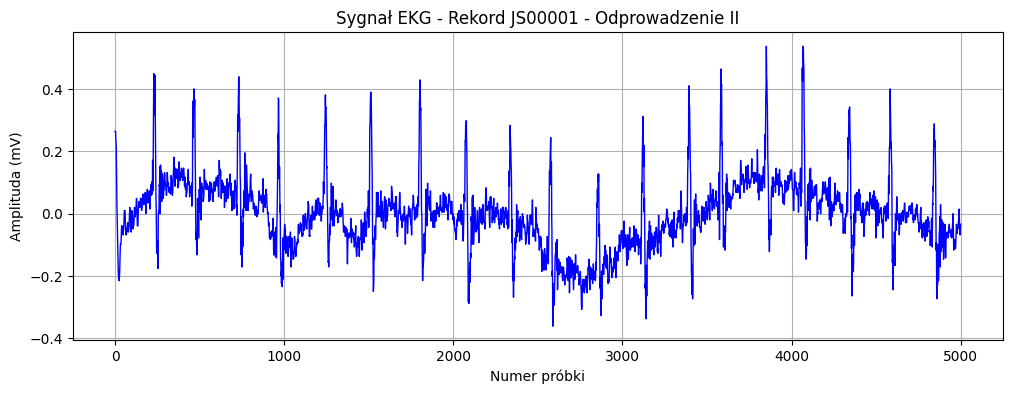


--- Pliki metadanych CSV w folderze głównym ---
Znaleziono: ConditionNames_SNOMED-CT.csv

Wczytano DataFrame z ConditionNames_SNOMED-CT.csv:


,Acronym Name,Full Name,Snomed_CT
0,1AVB,1 degree atrioventricular block,270492004
1,2AVB,2 degree atrioventricular block,195042002
2,2AVB1,2 degree atrioventricular block(Type one),54016002
3,2AVB2,2 degree atrioventricular block(Type two),28189009
4,3AVB,3 degree atrioventricular block,27885002


In [9]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt

record_path = r"C:\Users\Roch\physionet.org\files\ecg-arrhythmia\1.0.0\WFDBRecords\01\010\JS00001"

print(f"Wczytywanie rekordu: {record_path}")
signal, meta = wfdb.rdsamp(record_path)

print("\n--- Informacje o sygnale ---")
print(f"Wymiary macierzy sygnału: {signal.shape} (oczekiwane: 5000, 12)")
print(f"Częstotliwość próbkowania (fs): {meta['fs']} Hz")
print(f"Nazwy odprowadzeń (kanały): {meta['sig_name']}")

# Rysowanie jednego odprowadzenia (np. Lead II, który jest zazwyczaj pod indeksem 1)
plt.figure(figsize=(12, 4))
plt.plot(signal[:, 1], color='blue', linewidth=1) # signal[:, 1] bierze wszystkie próbki dla 2. kanału
plt.title("Sygnał EKG - Rekord JS00001 - Odprowadzenie II")
plt.xlabel("Numer próbki")
plt.ylabel("Amplituda (mV)")
plt.grid(True)
plt.show()

base_dir = r"C:\Users\Roch\physionet.org\files\ecg-arrhythmia\1.0.0"

csv_files = [f for f in os.listdir(base_dir) if f.endswith('.csv')]
print("\n--- Pliki metadanych CSV w folderze głównym ---")
if csv_files:
    for csv_file in csv_files:
        print(f"Znaleziono: {csv_file}")
        
    csv_path = os.path.join(base_dir, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"\nWczytano DataFrame z {csv_files[0]}:")
    display(df.head())
else:
    print("Nie znaleziono plików .csv w głównym folderze.")

## Krok 5 - czyszczenie danych

In [ ]:
import glob
import numpy as np

def wyczysc_i_weryfikuj_dane(base_dir, limit=1000):
    
    # Szukamy wszystkich plików .hea w podfolderach
    hea_files = glob.glob(os.path.join(base_dir, '**', '*.hea'), recursive=True)
    total_files = len(hea_files)
    
    if total_files == 0:
        print("Nie znaleziono plików .hea! Sprawdź ścieżkę.")
        return []
    
    czyste_rekordy = []
    licznik_uszkodzone_sygnaly = 0
    
    for idx, file_path in enumerate(hea_files[:limit]):
            
        # wfdb.rdsamp potrzebuje ścieżki bez rozszerzenia
        record_no_ext = os.path.splitext(file_path)[0]
        
        try:
            # Wczytujemy sam sygnał
            signal, _ = wfdb.rdsamp(record_no_ext)
            
            # Weryfikacja techniczna: 
            # 1. Musi być dokładnie 12 kanałów
            # 2. Sygnał nie może zawierać wartości NaN (Not-a-Number)
            if signal.shape[1] != 12 or np.isnan(signal).any():
                licznik_uszkodzone_sygnaly += 1
                continue
                
            # Jeśli wszystko jest OK, dodajemy do puli "czystych"
            czyste_rekordy.append(record_no_ext)
            
        except Exception as e:
            # Jeśli wfdb rzuci błędem przy wczytywaniu, uznajemy plik za uszkodzony
            licznik_uszkodzone_sygnaly += 1
            continue

    print("\n" + "="*40)
    print("      RAPORT Z CZYSZCZENIA DANYCH")
    print("="*40)
    print(f"Przeanalizowanych plików:         {limit}")
    print(f"❌ Odrzucone (błędy/NaN/brak leadów): {licznik_uszkodzone_sygnaly}")
    print(f"✅ Zaakceptowane do testu domeny:  {len(czyste_rekordy)}")
    print("="*40)
    
    return czyste_rekordy

sciezka_do_katalogu_z_danymi = r"C:\Users\Roch\physionet.org\files\ecg-arrhythmia\1.0.0"

lista_wszystkich_czystych = wyczysc_i_weryfikuj_dane(sciezka_do_katalogu_z_danymi, limit=None)

# Zapis do pliku, żeby nie tracić czasu przy kolejnych uruchomieniach
with open("valid_records.txt", "w") as f:
    for record in lista_wszystkich_czystych:
        f.write(record + "\n")

print(f"\n✅ Zapisano {len(lista_wszystkich_czystych)} czystych rekordów do valid_records.txt")

Rozpoczynam Krok 5: Czyszczenie danych (limit: 1000 plików)...

Znaleziono łącznie 45068 nagrań w bazie. Przetwarzam pierwszych 1000...
Przetworzono 200 plików...
Przetworzono 400 plików...
Przetworzono 600 plików...
Przetworzono 800 plików...

      RAPORT Z CZYSZCZENIA DANYCH
Przeanalizowanych plików:         1000
❌ Odrzucone (błędy/NaN/brak leadów): 2
✅ Zaakceptowane do testu domeny:  998


## Krok 6 - normalizacja
(wymagany model)